<div style="
background-color:#EAEAEA;
padding:15px;
border-left:5px solid #6C757D;
border-radius:6px;">

# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026
</div>

# Solar Diagnostic 2 - Probability and Flux
---

This notebook diagnoses the solar adiabatic-probability and flux layers: `tpeanuts.medium.solar.probability` and `tpeanuts.medium.solar.flux`. The associated pytest files are `tpeanuts.medium.solar.test.test5_probability` and `test6_flux`; here we keep visual checks for mass-eigenstate production weights, flavour probabilities, SNO-style electron-survival references, and flavour-resolved fluxes with source spectra.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Adiabatic-Probabilities) | **Adiabatic Probabilities** |
| [4](#4.-SNO-Reference-Comparison) | **SNO Reference Comparison** |
| [5](#5.-Solar-Flux) | **Solar Flux** |
| [?](#6.-Summary) | **Summary** |


## 0. Theory Background

### 0.1 Adiabatic Solar Propagation

Solar electron neutrinos are produced in matter as flavour states. In the standard adiabatic MSW approximation, the neutrino follows an instantaneous matter eigenstate as it propagates from the production point to the solar surface. The module `medium.solar.probability` first computes local production weights

$$
T_{ei}(E,r)=|\langle \nu_i^M(E,r)|\nu_e\rangle|^2,
$$

where $\nu_i^M$ denotes a matter eigenstate at the local electron density. For a source $s$ with normalized radial production profile $\hat f_s(r)$, the incoherent mass-basis weights at the solar surface are

$$
w_i^{(s)}(E)=\int_0^{R_\odot}\hat f_s(r)\,T_{ei}(E,r)\,dr.
$$

### 0.2 Projection to Flavour Probabilities

After leaving the Sun, the decohered mass-eigenstate mixture is projected onto final flavour using the vacuum PMNS matrix:

$$
P_{e\to\alpha}^{(s)}(E)=\sum_i |U_{\alpha i}|^2 w_i^{(s)}(E).
$$

The probability vector must be normalized, $\sum_\alpha P_{e\to\alpha}=1$, because the incoherent mass weights are normalized and the PMNS matrix is unitary.

### 0.3 Flux Construction

The module `medium.solar.flux` converts probabilities into flavour-resolved fluxes by multiplying by the total source flux $\Phi_s$ and, when supplied, a normalized spectral shape $g_s(E)$:

$$
\phi_{\alpha}^{(s)}(E)=\Phi_s\,g_s(E)\,P_{e\to\alpha}^{(s)}(E).
$$

For several sources, the source axis is preserved so each contribution can be inspected separately before summing over sources.

### References

- L. Wolfenstein, *Neutrino oscillations in matter*, Phys. Rev. D 17, 2369 (1978).
- S. P. Mikheyev and A. Yu. Smirnov, *Resonant amplification of neutrino oscillations in matter and solar-neutrino spectroscopy*, Nuovo Cimento C 9, 17 (1986).
- N. Vinyoles et al., *A new Generation of Standard Solar Models*, Astrophysical Journal 835, 202 (2017).


## 1. Libraries

All imports are centralized here. The notebook uses the package solar tables, the probability/flux APIs under test, and shared notebook helpers for styling and figure output.


In [1]:
from __future__ import annotations

from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.medium.solar.flux import solar_flux
from tpeanuts.medium.solar.io import default_solar_data_dir, load_spectrum_csv
from tpeanuts.medium.solar.profile import build_solar_profile
from tpeanuts.medium.solar.probability import psolar, solar_probability_mass
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import FLAVOUR_LABELS, save_and_show, to_numpy
from tpeanuts.util.context import RuntimeContext


## 2. Paths and Configuration

### 2.1 Paths

The output directory follows the notebook relative location below `notebooks/`: diagnostic figures from this notebook are saved under `diagnostic/solar`.


In [2]:
config = load_notebook_config()
OUTPUT_DIR = config.output_dir("diagnostic", "solar")
SHOW_PLOTS = config.show_plots
SOLAR_DATA_DIR = default_solar_data_dir()
SPECTRA_DIR = SOLAR_DATA_DIR / "spectra"

print(f"Repository root: {config.package_dir}")
print(f"Solar data directory: {SOLAR_DATA_DIR}")
print(f"Figure output directory: {OUTPUT_DIR}")


Repository root: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Solar data directory: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\solar
Figure output directory: v:\output\diagnostic\solar


### 2.2 Configuration

The notebook uses the `_SM_NUFIT52_NO` oscillation preset and the default solar profile selected by `tpeanuts.util.default`. A logarithmic energy grid is used for probability scans, while `8B` and `hep` spectra are used for flux diagnostics because these sources have broad high-energy spectra and SNO reference curves.

**Expected results**: probability vectors should stay normalized, $P_{ee}$ should decrease from the low-energy vacuum-averaged regime toward the high-energy MSW regime, and fluxes should preserve the probability shape while scaling by source normalizations and spectra.


In [3]:
ctx = RuntimeContext.resolve(config.device, config.dtype)
PROFILE = build_solar_profile(None, context=ctx)
OSCILLATION = OscillationParameters.from_preset("_SM_NUFIT52_NO", context=ctx)

ENERGY_MEV = torch.logspace(torch.log10(torch.tensor(0.1, device=ctx.device, dtype=ctx.dtype)), torch.log10(torch.tensor(20.0, device=ctx.device, dtype=ctx.dtype)), 180, device=ctx.device, dtype=ctx.dtype)
PROBABILITY_SOURCES = [source for source in ["pp", "7Be", "8B", "hep", "13N", "15O"] if source in PROFILE.fractions]
FLUX_SOURCES = [source for source in ["8B", "hep"] if source in PROFILE.fractions]

SPECTRA = {}
for source in FLUX_SOURCES:
    path = SPECTRA_DIR / f"spectrum_{source}.csv"
    if path.exists():
        SPECTRA[source] = load_spectrum_csv(path, device=ctx.device, dtype=ctx.dtype)

SNO_TABLES = {}
for source in FLUX_SOURCES:
    path = SOLAR_DATA_DIR / f"SNO_{source}.csv"
    if path.exists():
        SNO_TABLES[source] = pd.read_csv(path).dropna()

print(f"SolarProfile: n_r={PROFILE.radius.numel()}, device={PROFILE.device}, dtype={PROFILE.dtype}")
print("oscillation preset:", OSCILLATION.preset_name, OSCILLATION.ordering)
print("probability sources:", PROBABILITY_SOURCES)
print("flux sources:", FLUX_SOURCES)
print("spectra loaded:", sorted(SPECTRA))
print("SNO tables loaded:", sorted(SNO_TABLES))


SolarProfile: n_r=2000, device=cpu, dtype=torch.float64
oscillation preset: _SM_NUFIT52_NO NO
probability sources: ['pp', '7Be', '8B', 'hep', '13N', '15O']
flux sources: ['8B', 'hep']
spectra loaded: ['8B', 'hep']
SNO tables loaded: ['8B', 'hep']


### 2.3 Local Helpers

Only small plotting/data helpers are defined locally. Physics calculations are delegated to the package modules under diagnosis.


In [4]:
def interp_spectrum_to_energy(source: str, energy: torch.Tensor) -> torch.Tensor:
    table = SPECTRA[source]
    return torch.from_numpy(
        np.interp(
            to_numpy(energy),
            to_numpy(table["energy"]),
            to_numpy(table["spectrum"]),
            left=0.0,
            right=0.0,
        )
    ).to(device=energy.device, dtype=energy.dtype)


def interp_sno_pee(source: str, energy: torch.Tensor) -> torch.Tensor:
    table = SNO_TABLES[source]
    return torch.from_numpy(
        np.interp(
            to_numpy(energy),
            table["energy"].to_numpy(dtype=float),
            table["Pnuenue"].to_numpy(dtype=float),
            left=np.nan,
            right=np.nan,
        )
    ).to(device=energy.device, dtype=energy.dtype)


def source_probability_table(source: str, energy: torch.Tensor) -> pd.DataFrame:
    probability = psolar(OSCILLATION, energy, PROFILE, source)
    return pd.DataFrame(
        {
            "energy_MeV": to_numpy(energy),
            "P_nue": to_numpy(probability[:, 0]),
            "P_numu": to_numpy(probability[:, 1]),
            "P_nutau": to_numpy(probability[:, 2]),
            "sum": to_numpy(probability.sum(dim=-1)),
        }
    )


## 3. Adiabatic Probabilities

### 3.1 Flavour Probabilities by Source

This scan evaluates `psolar(oscillation, E, profile, source)` for representative solar sources.

**Expected results**: all probability vectors should sum to one. The electron survival probability should be larger at low energy and smaller for high-energy sources where MSW conversion is stronger.


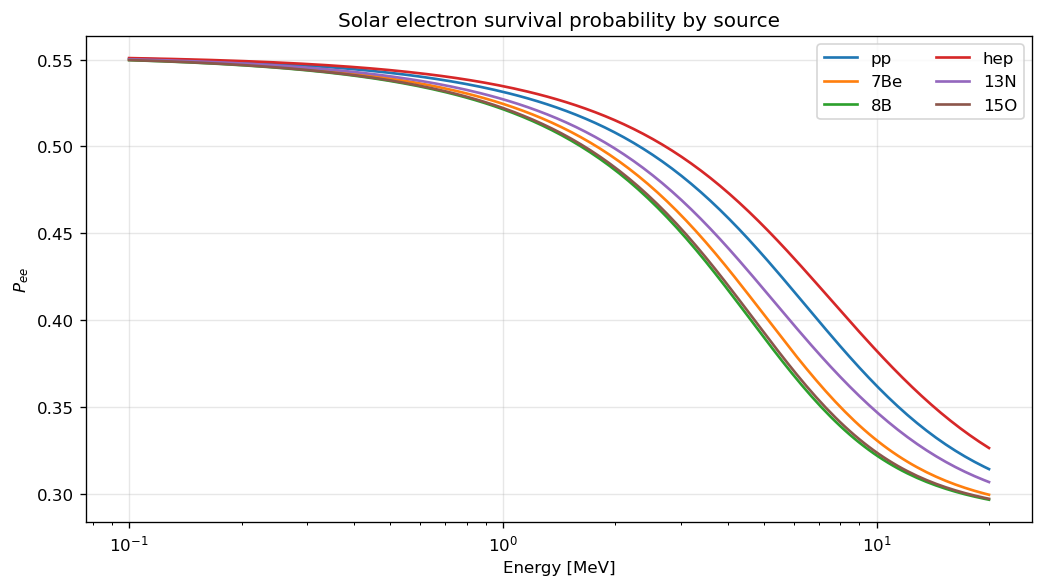

v:\output\diagnostic\solar\diagnostic2_solar_fig3_1_pee_by_source.png


,source,Pee_min,Pee_max,max_norm_error
0,pp,0.314253,0.550566,4.440892e-16
1,7Be,0.299491,0.549952,6.661338e-16
2,8B,0.296652,0.549684,3.330669e-16
3,hep,0.326405,0.550862,4.440892e-16
4,13N,0.306810,0.550190,3.330669e-16
5,15O,0.297162,0.549743,4.440892e-16


In [5]:
fig, ax = plt.subplots(figsize=(8.8, 5.0))
probability_summaries = []
for source in PROBABILITY_SOURCES:
    table = source_probability_table(source, ENERGY_MEV)
    probability_summaries.append(
        {
            "source": source,
            "Pee_min": table["P_nue"].min(),
            "Pee_max": table["P_nue"].max(),
            "max_norm_error": np.max(np.abs(table["sum"] - 1.0)),
        }
    )
    ax.plot(table["energy_MeV"], table["P_nue"], lw=1.6, label=source)

ax.set_xscale("log")
ax.set_xlabel("Energy [MeV]")
ax.set_ylabel(r"$P_{ee}$")
ax.set_title(r"Solar electron survival probability by source")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
fig.tight_layout()
save_and_show("diagnostic2_solar_fig3_1_pee_by_source.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

display(pd.DataFrame(probability_summaries))


### 3.2 Mass-Basis Weights

`solar_probability_mass` returns the incoherent mass-eigenstate mixture at the solar surface before vacuum PMNS projection.

**Expected results**: the mass weights should sum to one. At high energy, the second mass component dominates for standard LMA solar neutrinos produced in the dense core.


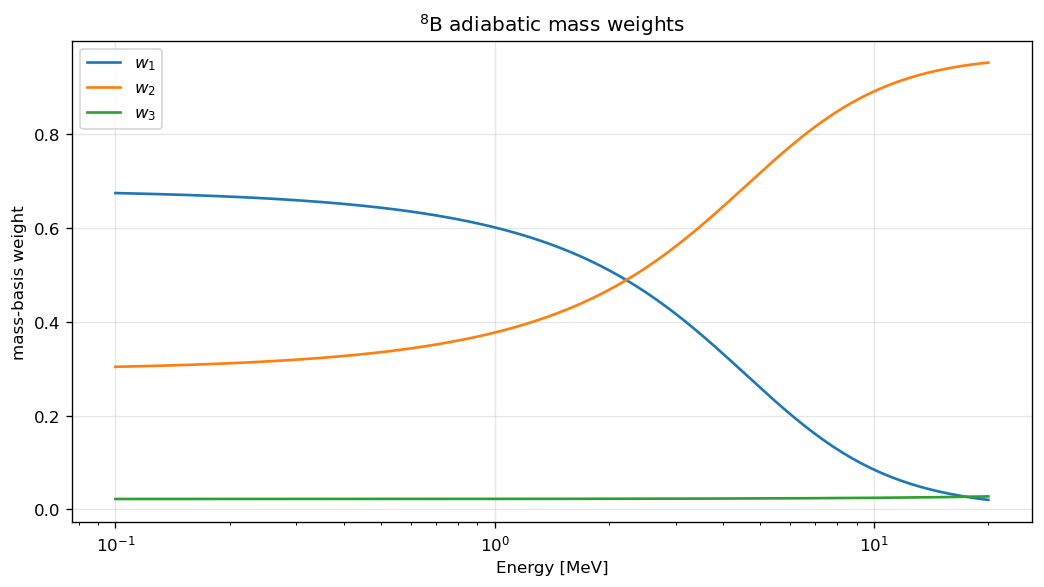

v:\output\diagnostic\solar\diagnostic2_solar_fig3_2_8b_mass_weights.png
max |sum_i w_i - 1|: 4.440892098500626e-16


In [6]:
source = "8B"
weights = solar_probability_mass(OSCILLATION, ENERGY_MEV, PROFILE, source)
fig, ax = plt.subplots(figsize=(8.8, 5.0))
for idx, label in enumerate([r"$w_1$", r"$w_2$", r"$w_3$"]):
    ax.plot(to_numpy(ENERGY_MEV), to_numpy(weights[:, idx]), lw=1.6, label=label)
ax.set_xscale("log")
ax.set_xlabel("Energy [MeV]")
ax.set_ylabel("mass-basis weight")
ax.set_title(r"$^8$B adiabatic mass weights")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
save_and_show("diagnostic2_solar_fig3_2_8b_mass_weights.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
print("max |sum_i w_i - 1|:", float(torch.max(torch.abs(weights.sum(dim=-1) - 1.0))))


## 4. SNO Reference Comparison

The packaged SNO reference tables provide an external electron-survival curve for `8B` and `hep`. This is a diagnostic overlay, not a strict unit test, because different input solar models and oscillation parameters can shift the curve slightly.

**Expected results**: the computed $P_{ee}$ should follow the same broad trend as the SNO reference curve in the high-energy region.


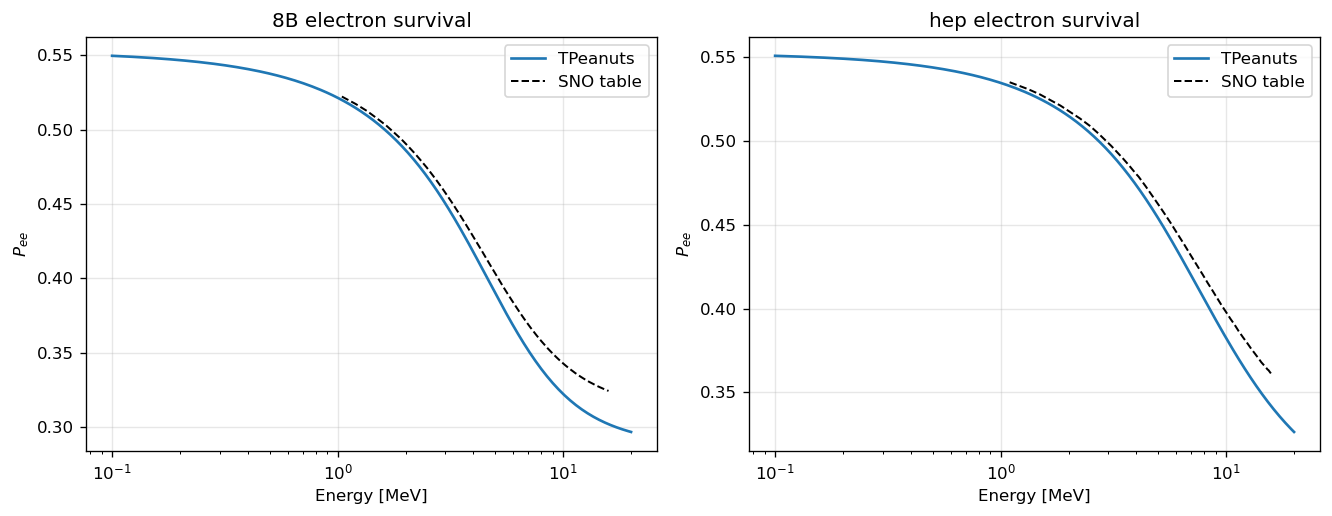

v:\output\diagnostic\solar\diagnostic2_solar_fig4_1_sno_pee_comparison.png


,source,max_abs_delta,rms_delta
0,8B,0.022372,0.013624
1,hep,0.019290,0.010172


In [7]:
fig, axes = plt.subplots(1, len(FLUX_SOURCES), figsize=(5.6 * len(FLUX_SOURCES), 4.4), squeeze=False)
comparison_rows = []
for ax, source in zip(axes[0], FLUX_SOURCES):
    probability = psolar(OSCILLATION, ENERGY_MEV, PROFILE, source)[:, 0]
    ax.plot(to_numpy(ENERGY_MEV), to_numpy(probability), lw=1.6, label="TPeanuts")
    if source in SNO_TABLES:
        sno = SNO_TABLES[source]
        ax.plot(sno["energy"], sno["Pnuenue"], "k--", lw=1.2, label="SNO table")
        sno_interp = interp_sno_pee(source, ENERGY_MEV)
        valid = torch.isfinite(sno_interp)
        diff = probability[valid] - sno_interp[valid]
        comparison_rows.append({"source": source, "max_abs_delta": float(torch.max(torch.abs(diff))), "rms_delta": float(torch.sqrt(torch.mean(diff**2)))})
    ax.set_xscale("log")
    ax.set_xlabel("Energy [MeV]")
    ax.set_ylabel(r"$P_{ee}$")
    ax.set_title(f"{source} electron survival")
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.tight_layout()
save_and_show("diagnostic2_solar_fig4_1_sno_pee_comparison.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

display(pd.DataFrame(comparison_rows))


## 5. Solar Flux

### 5.1 Flavour-Resolved Source Fluxes

This section evaluates `solar_flux` with interpolated spectral shapes. The plotted quantity is the source-normalized, spectrum-weighted flavour flux for each broad high-energy source.

**Expected results**: flavour fluxes should have the same energy support as the input spectra. Their sum over flavours should reconstruct the total source flux times the spectral weight.


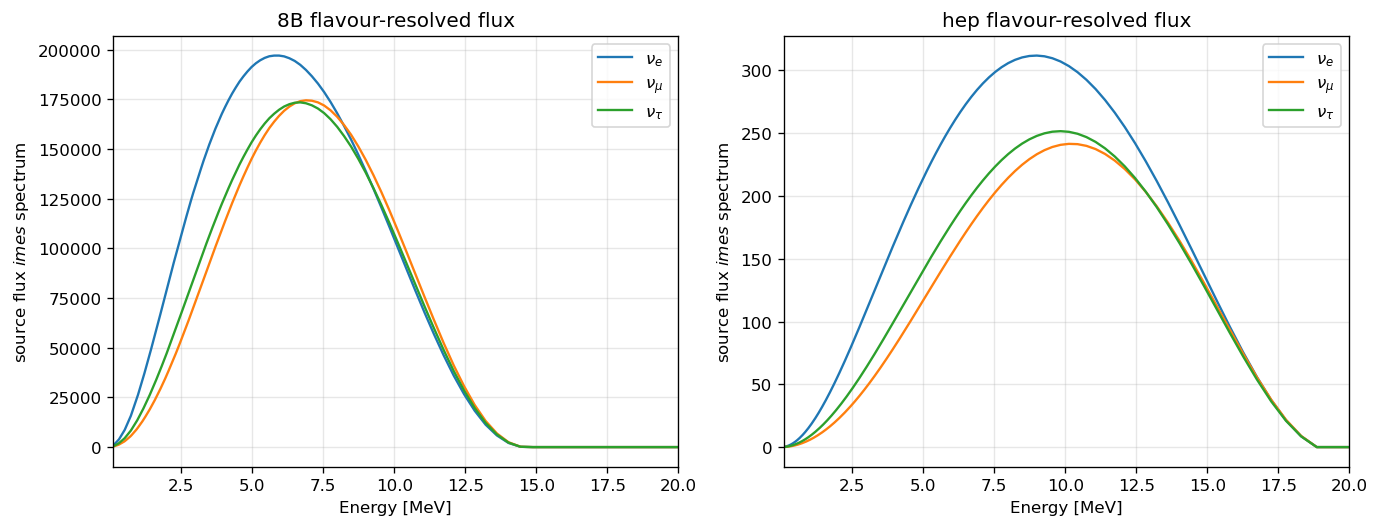

v:\output\diagnostic\solar\diagnostic2_solar_fig5_1_flavour_fluxes.png


,source,total_flux,max_sum_residual,spectrum_max
0,8B,4135000.0,2.328306e-10,0.130732
1,hep,8216.0,2.273737e-13,0.097367


In [8]:
fig, axes = plt.subplots(1, len(FLUX_SOURCES), figsize=(5.8 * len(FLUX_SOURCES), 4.5), squeeze=False)
flux_summaries = []
for ax, source in zip(axes[0], FLUX_SOURCES):
    spectrum = interp_spectrum_to_energy(source, ENERGY_MEV)
    flux = solar_flux(source, PROFILE, OSCILLATION, ENERGY_MEV, source_spectrum=spectrum)
    for idx, label in enumerate(FLAVOUR_LABELS):
        ax.plot(to_numpy(ENERGY_MEV), to_numpy(flux[:, idx]), lw=1.4, label=label)
    total_expected = PROFILE.flux(source) * spectrum
    residual = torch.max(torch.abs(flux.sum(dim=-1) - total_expected))
    flux_summaries.append({"source": source, "total_flux": float(PROFILE.flux(source)), "max_sum_residual": float(residual), "spectrum_max": float(spectrum.max())})
    ax.set_xlim(float(ENERGY_MEV[0]), float(ENERGY_MEV[-1]))
    ax.set_xlabel("Energy [MeV]")
    ax.set_ylabel(r"source flux $	imes$ spectrum")
    ax.set_title(f"{source} flavour-resolved flux")
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.tight_layout()
save_and_show("diagnostic2_solar_fig5_1_flavour_fluxes.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

display(pd.DataFrame(flux_summaries))


### 5.2 Distorted Electron Spectra

The electron-flavour flux is compared with the undistorted source spectrum scaled by the total source flux. Their ratio is exactly $P_{ee}(E)$ where the spectrum is non-zero.

**Expected results**: the distorted electron spectrum should lie below the undistorted spectrum by the electron survival factor.


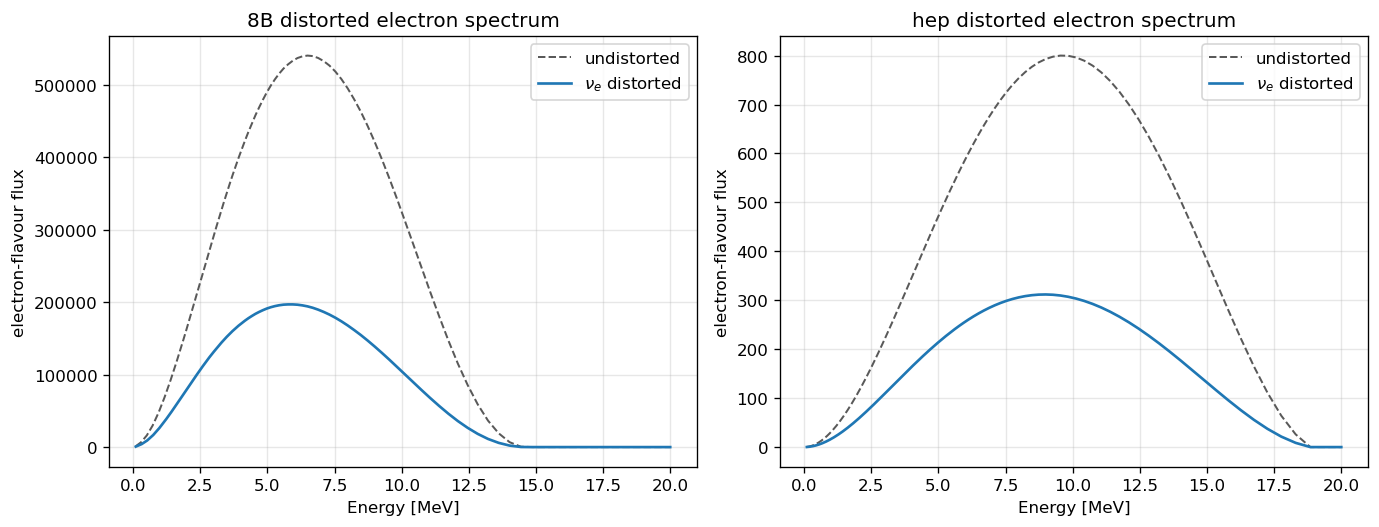

v:\output\diagnostic\solar\diagnostic2_solar_fig5_2_distorted_electron_spectra.png


In [9]:
fig, axes = plt.subplots(1, len(FLUX_SOURCES), figsize=(5.8 * len(FLUX_SOURCES), 4.5), squeeze=False)
for ax, source in zip(axes[0], FLUX_SOURCES):
    spectrum = interp_spectrum_to_energy(source, ENERGY_MEV)
    flux = solar_flux(source, PROFILE, OSCILLATION, ENERGY_MEV, source_spectrum=spectrum)
    undistorted = PROFILE.flux(source) * spectrum
    ax.plot(to_numpy(ENERGY_MEV), to_numpy(undistorted), color="0.35", ls="--", lw=1.2, label="undistorted")
    ax.plot(to_numpy(ENERGY_MEV), to_numpy(flux[:, 0]), color="C0", lw=1.6, label=r"$\nu_e$ distorted")
    ax.set_xlabel("Energy [MeV]")
    ax.set_ylabel("electron-flavour flux")
    ax.set_title(f"{source} distorted electron spectrum")
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.tight_layout()
save_and_show("diagnostic2_solar_fig5_2_distorted_electron_spectra.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 6. Summary

The probability layer converts local matter-mixing weights into normalized mass-basis and flavour-basis probabilities. The diagnostic scans show the expected MSW trend: $P_{ee}$ is high in the low-energy vacuum-averaged regime and lower for high-energy solar neutrinos. The mass-basis view makes this transition visible before the PMNS projection.

The flux layer performs a deliberately thin operation: it preserves the probability tensor shape and multiplies by source flux normalizations and optional spectra. The flux plots confirm that the flavour sum reconstructs the source-normalized spectrum, while the electron-flavour component is the corresponding survival-probability-distorted spectrum.
